In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [20]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [19]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [21]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

df[cols] = df[cols].replace(0, np.nan)

In [22]:
df.fillna(df.mean(), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27,0
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47,1


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.drop_duplicates(inplace=True)

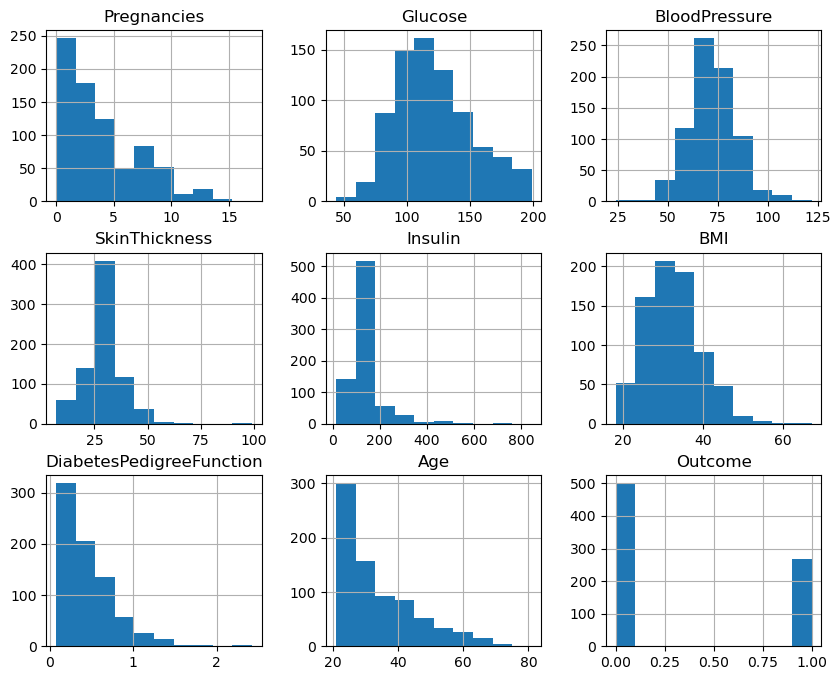

In [25]:
df.hist(figsize=(10,8))
plt.show()

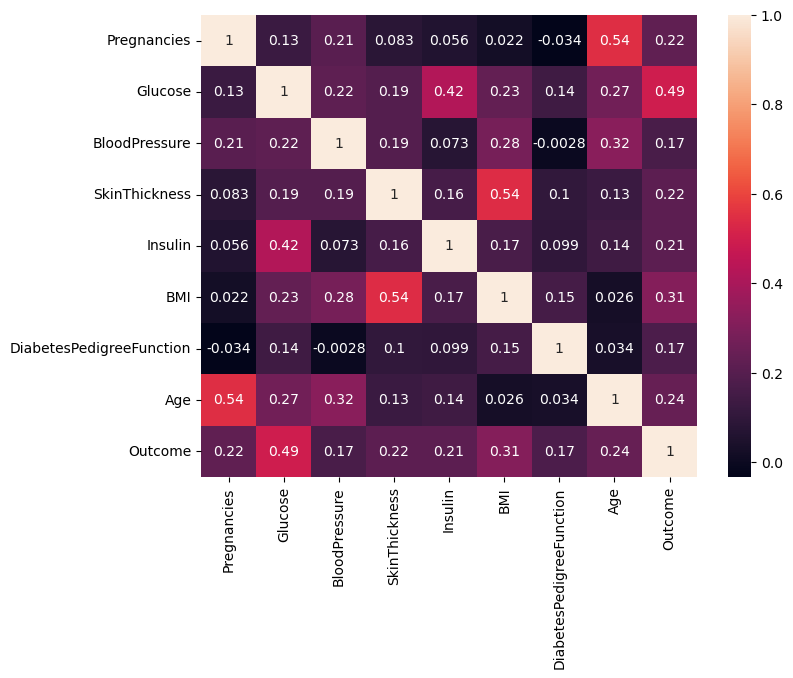

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [27]:
df.corr()["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.492928
BMI                         0.311924
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.215299
Insulin                     0.214411
DiabetesPedigreeFunction    0.173844
BloodPressure               0.166074
Name: Outcome, dtype: float64

In [28]:
X = df[["Glucose","BMI","Age"]]
y = df["Outcome"]

In [29]:
X = (X - X.mean()) / X.std()

In [30]:
X = X.values
y = y.values

In [31]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [32]:
weights = np.zeros(X.shape[1])
bias = 0

In [33]:
learning_rate = 0.01
epochs = 1000

for i in range(epochs):
    
    linear_model = np.dot(X, weights) + bias
    
    y_pred = sigmoid(linear_model)
    
    dw = (1/len(y)) * np.dot(X.T, (y_pred - y))
    db = (1/len(y)) * np.sum(y_pred - y)
    
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

In [34]:
def predict(X):
    
    linear_model = np.dot(X, weights) + bias
    y_pred = sigmoid(linear_model)
    
    predictions = [1 if i > 0.5 else 0 for i in y_pred]
    
    return predictions

In [35]:
predictions = predict(X)

accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)

Accuracy: 0.7708333333333334


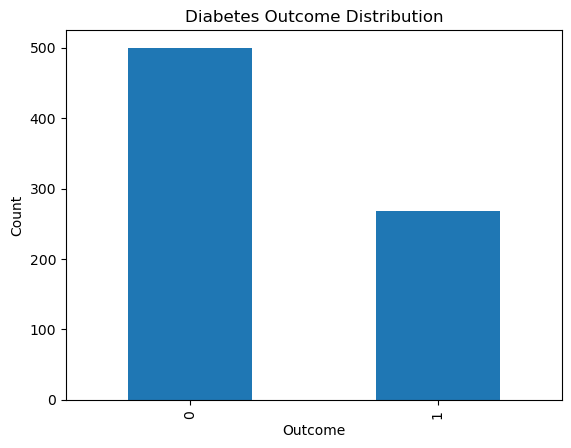

In [36]:
import matplotlib.pyplot as plt

df["Outcome"].value_counts().plot(kind="bar")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()